In [1]:
from utils import State
from tensor_contraction import TensorNetwork, TensorNetworkOptimizer
import numpy as np

In [2]:
'''
Generate matrix lambd[i,j]
lambd[i,j] == 1 => RZZ will act on i-th and j-th qubit
'''
def generate_lambda(probability, n):
    lambd = np.zeros((n, n))
    for i in range(n):
        for j in range(i):
            if np.random.rand() < probability:
                lambd[i, j] = 1
    return lambd

In [3]:
n_layers = 2
prob = 1.0
n_qubits = 4

gammas = np.random.uniform(0, 2*np.pi, size=n_layers)
betas = np.random.uniform(0, 2*np.pi, size=n_layers)
lambd = generate_lambda(prob, n_qubits)

In [4]:
'''
Generate tensor net without measurement layer, so raw output state is generated after contraction
'''
net = TensorNetwork.qaoa_like_from_params(lambd, gammas, betas, generate_meas_layer=False)

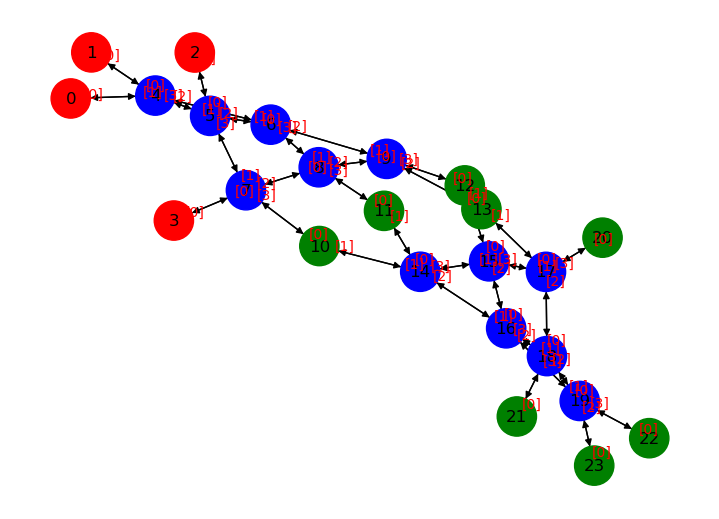

In [5]:
net.draw_network()

In [6]:
'''
Optimize network, and show ouptut state after greedy sequence
'''
opt = TensorNetworkOptimizer(net)
seq, cost = opt.optimize_network(k=2)
print(seq)
for (i,j) in seq:
    net.merge_nodes(i,j, actually_contract=True)
print(net.nodes[0].tensor)

[(1, 0), (2, 0), (10, 3), (12, 11), (20, 13), (4, 0), (5, 0), (6, 0), (7, 3), (3, 0), (21, 18), (22, 19), (8, 0), (9, 0), (11, 0), (14, 0), (15, 0), (16, 0), (17, 13), (13, 0), (18, 0), (19, 0), (23, 0)]
[[[[ 0.04027473-0.04388317j  0.35076232+0.00054951j]
   [ 0.35076232+0.00054951j -0.01034084-0.03648461j]]

  [[ 0.35076232+0.00054951j -0.01034084-0.03648461j]
   [-0.01034084-0.03648461j  0.35076232+0.00054951j]]]


 [[[ 0.35076232+0.00054951j -0.01034084-0.03648461j]
   [-0.01034084-0.03648461j  0.35076232+0.00054951j]]

  [[-0.01034084-0.03648461j  0.35076232+0.00054951j]
   [ 0.35076232+0.00054951j  0.04027473-0.04388317j]]]]


In [7]:
'''
run qaoa gate by gate
'''
s = State(n_qubits)
s.run_qaoa(lambd, gammas, betas)
s.state

array([[[[ 0.04027473-0.04388317j,  0.35076232+0.00054951j],
         [ 0.35076232+0.00054951j, -0.01034084-0.03648461j]],

        [[ 0.35076232+0.00054951j, -0.01034084-0.03648461j],
         [-0.01034084-0.03648461j,  0.35076232+0.00054951j]]],


       [[[ 0.35076232+0.00054951j, -0.01034084-0.03648461j],
         [-0.01034084-0.03648461j,  0.35076232+0.00054951j]],

        [[-0.01034084-0.03648461j,  0.35076232+0.00054951j],
         [ 0.35076232+0.00054951j,  0.04027473-0.04388317j]]]])

In [8]:
'''
Verify result is the same
'''
np.allclose(s.state, net.nodes[0].tensor)

True